# RoBERTA on agnews
### LLM data generation: **"deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"**

https://huggingface.co/FacebookAI/roberta-base  
https://huggingface.co/FacebookAI/roberta-large

- total number of train samples: 500
- total number of test&nbsp; samples: 500
- classification model: "roberta-large"
- dataset: agnews

Generation methods:
- **A** generic augmentation
- **B** targeted augmentation
- **C** unsupervised context augmentation
- **D** real data with labels generated in zero-shot settings

TESTS:
1. 500 real
2. 250 real + 250 synthetic (A, B, C, D) [50% synthetic]
3. 50 real + 450 synthetic (A, B, C, D) [90% synthetic]
4. 500 synthetic (A, B, C, D) [100% synthetic]

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.model_selection import train_test_split

# CHANGE WORKING DIRECTORY TO ROOT
current_dir = os.path.basename(os.getcwd())
if current_dir == "src":
    os.chdir("..") # Move up by 1
elif os.path.basename(os.getcwd()) == "bai-thesis-nlp":  
    pass # If already at root, stay there
else:
    os.chdir("../..") # Move up by 2 otherwise
     
from src._utils._helpers import get_generated_examples_df
from src._utils._data_analysis_helpers import plot_f1_generationMethod
from src._utils._run_multiclassRoBERTA import main_multiclassRoBERTA

In [ ]:
LLM_NAME = "DeepSeek-R1-Distill-Qwen-1.5B"
DATASET_NAME = "agnews"
FOLDER_DIR = "src/"+DATASET_NAME+"/experiments/RoBERTA_500samples/data_"+LLM_NAME
os.makedirs(FOLDER_DIR, exist_ok=True)
LOG_DIR = os.path.join(FOLDER_DIR, "RoBERTA_log.json")

### LOAD DATA ###
# real data
real_train_df = pd.read_csv("real_data/train/"+DATASET_NAME+"trainAll.csv").rename(columns={"2": "text", "3": "label"})
real_train_df.drop(columns=["0", "1"], inplace=True)

# Take 500 samples for dev set
real_train_df, dev_df = train_test_split(real_train_df, test_size=500, random_state=42, stratify=real_train_df["label"])
# Store the dev set into a CSV file
dev_df.to_csv(os.path.join(FOLDER_DIR, "dev_set.csv"), index=False)

# synthetic data (generic, targeted and unsupervised context)
SYNTHETIC_DATA_DIR = "synthetic_data/datasets/"+LLM_NAME+"/"
syn_generic_df, _ = get_generated_examples_df(SYNTHETIC_DATA_DIR+DATASET_NAME+"_baseline_500.json")
syn_targeted_df, _ = get_generated_examples_df(SYNTHETIC_DATA_DIR+DATASET_NAME+"_targeted+tags_500.json")
syn_targeted_df = syn_targeted_df.drop(columns=["phenomena"])
syn_unsupContext_df, _ = get_generated_examples_df(SYNTHETIC_DATA_DIR+DATASET_NAME+"_unsupervisedContext_500.json")
syn_unsupContext_df = syn_unsupContext_df.drop(columns=["context_examples"])

In [3]:
# zeroshot data (real data + zeroshot generated labels)
data = "./src/"+DATASET_NAME+"/experiments/fewshotCasualLM_500samples/"+LLM_NAME+"_zeroshot_TRAIN.csv"
zeroshot_df = pd.read_csv(data)

display(zeroshot_df.head())
acc = sum(zeroshot_df['label'] == zeroshot_df['predicted_label']) / len(zeroshot_df)
print(f"Accuracy {acc:.3f} | number of samples: {zeroshot_df.shape[0]}"),

# keep only the labels that are allowed
labels = zeroshot_df['label'].unique()
zeroshot_df = zeroshot_df[zeroshot_df["predicted_label"].isin(labels)].reset_index(drop=True)
new_acc = sum(zeroshot_df['label'] == zeroshot_df['predicted_label']) / len(zeroshot_df)

# set the predicted label as the real label for training
zeroshot_df['label'] = zeroshot_df["predicted_label"]
zeroshot_df = zeroshot_df.drop(columns=["predicted_label"])

print("Filter out labels that are not in the real data. Results:")
print(f"Accuracy {new_acc:.3f} | number of samples: {zeroshot_df.shape[0]}")

,text,label,predicted_label
0,Alternative Web browsers like Safari and Firef...,Sci/Tech,?
1,NEW YORK - Eli Manning is undeniably the Giant...,Sports,?
2,BEIJING (Reuters) - Jelena Dokic ran true to ...,Sports,?
3,AP - A University of Idaho football player was...,Sports,?
4,&lt;p&gt;\&lt;/p&gt;&lt;p&gt; GENEVA (Reuters)...,Sci/Tech,______


Accuracy 0.045 | number of samples: 2179
Filter out labels that are not in the real data. Results:
Accuracy 0.444 | number of samples: 223


In [4]:
results = []

def get_results(details):
    """Just get useful results from the details"""
    res = {}
    res["generation_method"] = details["generation_method"] if details["generation_method"] else "real"
    res["synthetic_ratio"] = details["synthetic_ratio"]
    for key, value in details["metrics_dev"].items():
        res[key] = value
    res["train_time"] = details["train_time"]
    res["eval_time"] = details["eval_time"]
    
    df = pd.DataFrame([res])
    display(df.round(3))
    return df

In [5]:
base_config = {
    "real_df": real_train_df,
    # "synth_df": None/syn_generic_df..,
    "dev_df": dev_df,
    # "synth_ratio": 0.0/0.5..,
    "max_samples": 500,
    "epochs": 8,
    "batch_size": 16,
    "output_dir":FOLDER_DIR,
    "log_dir": LOG_DIR,
    # "generation_method": None/"generic"/"targeted",
    "save_model": False,
    "save_dataset": True,
}

## 1. 500 real

In [6]:
config = base_config.copy()
config["synth_df"] = None
config["synth_ratio"] = 0.0
config["generation_method"] = None

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.252500,0.977969,0.740000,0.430538,0.740000
2,0.563700,0.462281,0.890000,0.815641,0.890000
3,0.222600,0.318425,0.914000,0.870597,0.914000
4,0.109400,0.427912,0.910000,0.864207,0.910000
5,0.059400,0.490521,0.912000,0.867861,0.912000
6,0.029300,0.538154,0.918000,0.869133,0.918000
7,0.037300,0.500496,0.918000,0.873182,0.918000
8,0.018300,0.498331,0.916000,0.869508,0.916000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,real,0.0,0.918,0.869,0.918,194.376,4.129


## 2. 250 real + 250 synthetic

A. Generic augmentation

In [7]:
config = base_config.copy()
config["synth_df"] = syn_generic_df # Generic Augmentation
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["generation_method"] = "generic"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.360100,1.246296,0.372000,0.135569,0.372000
2,1.138300,0.432095,0.884000,0.821891,0.884000
3,0.592500,0.343041,0.894000,0.856194,0.894000
4,0.342000,0.304781,0.906000,0.862807,0.906000
5,0.225000,0.335748,0.906000,0.857243,0.906000
6,0.154600,0.343926,0.904000,0.860719,0.904000
7,0.098400,0.374216,0.898000,0.855768,0.898000
8,0.079600,0.405051,0.904000,0.859633,0.904000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,generic,0.5,0.906,0.863,0.906,191.734,4.125


B. Targeted augmentation

In [9]:
config = base_config.copy()
config["synth_df"] = syn_targeted_df # Targeted Augmentation
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["generation_method"] = "targeted"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.029500,0.343415,0.884000,0.805235,0.884000
2,0.377600,0.428534,0.856000,0.795615,0.856000
3,0.287500,0.387283,0.878000,0.831618,0.878000
4,0.102200,0.452338,0.886000,0.841624,0.886000
5,0.049500,0.574933,0.892000,0.843962,0.892000
6,0.042700,0.538313,0.900000,0.850534,0.900000
7,0.003000,0.550513,0.898000,0.848864,0.898000
8,0.002100,0.550181,0.898000,0.847552,0.898000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,targeted,0.5,0.9,0.851,0.9,191.476,4.118


C. Unsupervised Context augmentation

In [10]:
config = base_config.copy()
config["synth_df"] = syn_unsupContext_df # Unsupervised Context Augmentation
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["generation_method"] = "unsupContext"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.994000,0.422437,0.880000,0.817051,0.880000
2,0.488300,0.325421,0.896000,0.847909,0.896000
3,0.360000,0.337701,0.908000,0.864906,0.908000
4,0.218000,0.356105,0.894000,0.862110,0.894000
5,0.134900,0.338906,0.906000,0.871922,0.906000
6,0.063800,0.388037,0.908000,0.867565,0.908000
7,0.037400,0.441910,0.904000,0.869229,0.904000
8,0.021300,0.436820,0.908000,0.872305,0.908000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,unsupContext,0.5,0.908,0.865,0.908,192.503,4.127


D. Zeroshot labels

In [11]:
config = base_config.copy()
config["synth_df"] = zeroshot_df # real data with labels predicted in zero-shot setting
config["synth_ratio"] = 0.5 # 50% of the data is synthetic
config["generation_method"] = "zeroshotLabels"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.148700,0.566729,0.778000,0.567710,0.778000
2,0.480600,0.327909,0.892000,0.848588,0.892000
3,0.256000,0.356364,0.914000,0.874275,0.914000
4,0.200800,0.389416,0.908000,0.870797,0.908000
5,0.075700,0.476168,0.888000,0.840516,0.888000
6,0.030200,0.460315,0.910000,0.876704,0.910000
7,0.010900,0.468008,0.912000,0.874753,0.912000
8,0.003900,0.464568,0.910000,0.872400,0.910000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,zeroshotLabels,0.5,0.914,0.874,0.914,159.206,4.116


## 3. 50 real + 450 synthetic
A. Generic augmentation

In [12]:
config = base_config.copy()
config["synth_df"] = syn_generic_df # Generic Augmentation
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["generation_method"] = "generic"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.139500,0.549779,0.868000,0.815471,0.868000
2,0.627400,0.478231,0.840000,0.749933,0.840000
3,0.452400,0.501387,0.806000,0.764742,0.806000
4,0.323800,0.410866,0.864000,0.822203,0.864000
5,0.240400,0.493466,0.828000,0.784671,0.828000
6,0.160800,0.462883,0.840000,0.799086,0.840000
7,0.125200,0.532602,0.826000,0.785236,0.826000
8,0.093500,0.503128,0.834000,0.789963,0.834000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,generic,0.9,0.868,0.815,0.868,192.409,4.126


B. Targeted augmentation

In [13]:
config = base_config.copy()
config["synth_df"] = syn_targeted_df # Targeted Augmentation
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["generation_method"] = "targeted"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.946000,0.570443,0.830000,0.750301,0.830000
2,0.385900,0.424750,0.860000,0.796859,0.860000
3,0.274500,0.411457,0.870000,0.810155,0.870000
4,0.142800,0.879624,0.788000,0.714288,0.788000
5,0.086300,0.658001,0.844000,0.784824,0.844000
6,0.045900,0.793917,0.820000,0.761928,0.820000
7,0.028100,0.729129,0.842000,0.779004,0.842000
8,0.014100,0.737501,0.838000,0.777181,0.838000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,targeted,0.9,0.87,0.81,0.87,192.3,4.119


C. Unsupervised Context augmentation

In [14]:
config = base_config.copy()
config["synth_df"] = syn_unsupContext_df # Unsupervised Context Augmentation
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["generation_method"] = "unsupContext"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.003700,1.026883,0.548000,0.473927,0.548000
2,0.625400,0.462507,0.830000,0.775278,0.830000
3,0.452900,0.547126,0.804000,0.760613,0.804000
4,0.327500,0.435556,0.854000,0.808307,0.854000
5,0.191300,0.577363,0.798000,0.755656,0.798000
6,0.101900,0.525943,0.830000,0.776370,0.830000
7,0.045600,0.573204,0.840000,0.791934,0.840000
8,0.031300,0.572431,0.844000,0.797392,0.844000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,unsupContext,0.9,0.854,0.808,0.854,192.388,4.127


D. Zeroshot labels

In [15]:
config = base_config.copy()
config["synth_df"] = zeroshot_df # real data with labels predicted in zero-shot setting
config["synth_ratio"] = 0.9 # 90% of the data is synthetic
config["generation_method"] = "zeroshotLabels"

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.106600,1.318552,0.372000,0.135569,0.372000
2,0.999900,1.346438,0.372000,0.135569,0.372000
3,0.908200,1.283989,0.374000,0.138426,0.374000
4,0.689200,0.952771,0.686000,0.404001,0.686000
5,0.559000,1.067591,0.554000,0.319972,0.554000
6,0.412500,0.993676,0.572000,0.391505,0.572000
7,0.291900,0.882274,0.632000,0.495051,0.632000
8,0.243600,0.939016,0.622000,0.470998,0.622000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,zeroshotLabels,0.9,0.686,0.404,0.686,132.177,4.124


## 4. 500 synthetic
A. Generic augmentation

In [16]:
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = syn_generic_df # Generic Augmentation
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["generation_method"] = "generic"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.028000,0.962252,0.578000,0.558116,0.578000
2,0.494400,0.958245,0.616000,0.589481,0.616000
3,0.358300,0.854678,0.698000,0.658720,0.698000
4,0.247300,1.113758,0.606000,0.580402,0.606000
5,0.165400,1.001864,0.646000,0.624999,0.646000
6,0.198200,1.282210,0.598000,0.569691,0.598000
7,0.112200,1.391574,0.600000,0.571890,0.600000
8,0.092400,1.464666,0.608000,0.577089,0.608000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,generic,1.0,0.698,0.659,0.698,191.911,4.125


B. Targeted augmentation

In [17]:
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = syn_targeted_df # Targeted Augmentation
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["generation_method"] = "targeted"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.167700,1.004960,0.590000,0.528645,0.590000
2,0.438600,0.939663,0.640000,0.587290,0.640000
3,0.228000,0.935637,0.658000,0.614550,0.658000
4,0.144400,1.479858,0.572000,0.529344,0.572000
5,0.121700,1.428262,0.606000,0.561997,0.606000
6,0.051500,1.360776,0.638000,0.591139,0.638000
7,0.023700,1.495692,0.634000,0.587414,0.634000
8,0.012100,1.623476,0.618000,0.573084,0.618000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,targeted,1.0,0.658,0.615,0.658,192.304,4.126


C. Unsupervised Context augmentation

In [18]:
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = syn_unsupContext_df # Unsupervised Context Augmentation
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["generation_method"] = "unsupContext"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,1.045500,1.025145,0.510000,0.378975,0.510000
2,0.644200,0.878264,0.572000,0.481979,0.572000
3,0.460700,0.621031,0.758000,0.689625,0.758000
4,0.292200,0.725749,0.714000,0.632600,0.714000
5,0.193400,0.794542,0.704000,0.618679,0.704000
6,0.105700,0.837540,0.722000,0.633690,0.722000
7,0.048200,1.015920,0.700000,0.613842,0.700000
8,0.031200,1.094445,0.698000,0.618694,0.698000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,unsupContext,1.0,0.758,0.69,0.758,192.64,4.126


D. Zeroshot labels

In [19]:
config = base_config.copy()
config["real_df"] = None
config["synth_df"] = zeroshot_df # real data with labels predicted in zero-shot setting
config["synth_ratio"] = 1.0 # 100% of the data is synthetic
config["generation_method"] = "zeroshotLabels"
config["save_dataset"] = False

train_details = main_multiclassRoBERTA(**config)
results.append(get_results(train_details))

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Accuracy
1,0.537100,2.360570,0.372000,0.135569,0.372000
2,0.377800,3.336321,0.372000,0.135569,0.372000
3,0.350600,3.100165,0.372000,0.135569,0.372000
4,0.324800,2.221559,0.372000,0.135569,0.372000
5,0.289300,3.332025,0.372000,0.135569,0.372000
6,0.263300,3.076204,0.372000,0.135569,0.372000
7,0.201500,3.613680,0.372000,0.135569,0.372000
8,0.208500,3.757242,0.372000,0.135569,0.372000


,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,zeroshotLabels,1.0,0.372,0.136,0.372,149.657,4.123



---
# Results

In [ ]:
df_results = pd.concat(results).reset_index(drop=True)
df_results.to_csv(os.path.join(FOLDER_DIR, "RoBERTA_results_dev.csv"), index=False)
display(df_results.round(3))

,generation_method,synthetic_ratio,micro-f1,macro-f1,accuracy,train_time,eval_time
0,real,0.0,0.918,0.869,0.918,194.376,4.129
1,generic,0.5,0.906,0.863,0.906,191.734,4.125
2,targeted,0.5,0.900,0.851,0.900,191.476,4.118
3,unsupContext,0.5,0.908,0.865,0.908,192.503,4.127
4,zeroshotLabels,0.5,0.914,0.874,0.914,159.206,4.116
5,generic,0.9,0.868,0.815,0.868,192.409,4.126
6,targeted,0.9,0.870,0.810,0.870,192.300,4.119
7,unsupContext,0.9,0.854,0.808,0.854,192.388,4.127
8,zeroshotLabels,0.9,0.686,0.404,0.686,132.177,4.124
9,generic,1.0,0.698,0.659,0.698,191.911,4.125


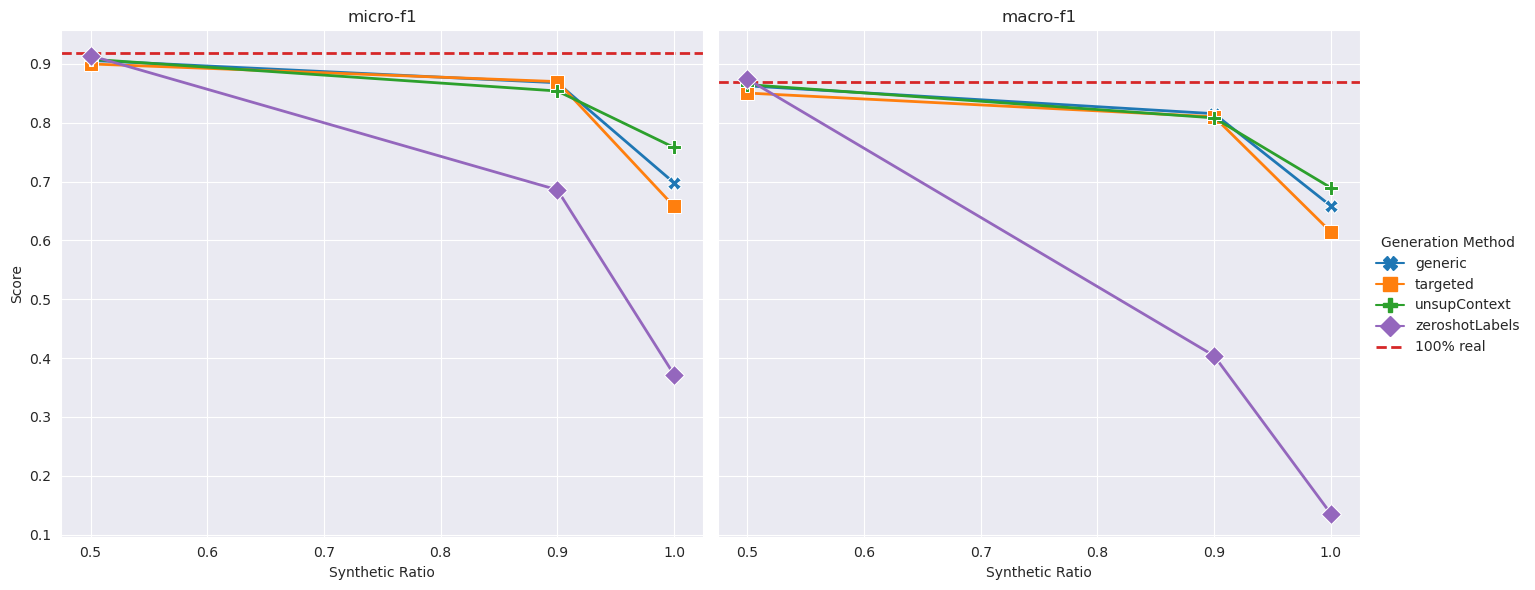

In [3]:
df_results = pd.read_csv(os.path.join(FOLDER_DIR, "RoBERTA_results_dev.csv"))

plot_f1_generationMethod(df=df_results, x_col="synthetic_ratio", hue_col="generation_method")